## UTS

## SOAL 1

In [1]:
!pip install Sastrawi
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('Berita.csv')
pd.set_option('display.max_rows', None)
print("Jumlah total berita:", len(df))

display(df)

Jumlah total berita: 1500


,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
5,6,AHY Buka-bukaan Nasib Kelanjutan Pembangunan I...,Menko Bidang Infrastruktur dan Pembangunan Kew...,"Minggu, 01 Des 2024 18:20 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
6,7,Badan Gizi Soal Biaya Makan Gratis Rp10 Ribu: ...,Kepala Badan Gizi Nasional Dadan Hindayana men...,"Senin, 02 Des 2024 21:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412022...
7,8,Zulhas Minta Tambahan Anggaran Rp510 M Demi Ca...,Menteri Koordinator Bidang Pangan Zulkifli Has...,"Senin, 02 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412021...
8,9,PLN Akan Uji Coba PLTS IKN 22 Desember,Uji coba alias commissioning pembangkit listri...,"Senin, 02 Des 2024 20:20 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412021...
9,10,"Profil Jhony Saputra, Anak Haji Isam yang Jadi...",Anak crazy rich pengusaha sawit Kalimantan Sam...,"Senin, 02 Des 2024 20:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412021...


In [ ]:
import pandas as pd
import re

# --- 1. Baca dataset ---
df = pd.read_csv("Berita.csv") # Changed from pd.read_excel("Berita.xlsx")
print("Jumlah total data:", len(df))

# --- 2. Bersihkan data kosong atau duplikat ---
df = df.drop_duplicates(subset=["berita"])
df = df.dropna(subset=["berita"])
df = df.reset_index(drop=True)

# --- 3. Fungsi pembersihan teks cepat ---
def clean_text_fast(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # hapus angka dan tanda baca
    text = re.sub(r'\s+', ' ', text).strip()   # hapus spasi berlebih
    return text

# --- 4. Terapkan pembersihan ---
df['clean_text'] = df['berita'].apply(clean_text_fast)

# --- 5. Tampilkan hasil ---
print("=== Contoh hasil preprocessing cepat ===")
display(df[['judul', 'berita', 'clean_text']].head(10))

Jumlah total data: 1500
=== Contoh hasil preprocessing cepat ===


,judul,berita,clean_text
0,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,menteri koordinator menko bidang perekonomian ...
1,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",dalam rangka memeriahkan hari jadi ke pt surab...
2,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,wacana presiden prabowo subianto akan membentu...
3,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,bpjs ketenagakerjaan dan kementerian agama kem...
4,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,pemerintah akan segera membentuk satuan tugas ...
5,AHY Buka-bukaan Nasib Kelanjutan Pembangunan I...,Menko Bidang Infrastruktur dan Pembangunan Kew...,menko bidang infrastruktur dan pembangunan kew...
6,Badan Gizi Soal Biaya Makan Gratis Rp10 Ribu: ...,Kepala Badan Gizi Nasional Dadan Hindayana men...,kepala badan gizi nasional dadan hindayana men...
7,Zulhas Minta Tambahan Anggaran Rp510 M Demi Ca...,Menteri Koordinator Bidang Pangan Zulkifli Has...,menteri koordinator bidang pangan zulkifli has...
8,PLN Akan Uji Coba PLTS IKN 22 Desember,Uji coba alias commissioning pembangkit listri...,uji coba alias commissioning pembangkit listri...
9,"Profil Jhony Saputra, Anak Haji Isam yang Jadi...",Anak crazy rich pengusaha sawit Kalimantan Sam...,anak crazy rich pengusaha sawit kalimantan sam...


In [ ]:
import gensim
from gensim import corpora
import numpy as np
import pandas as pd

# --- Tokenisasi dari teks bersih ---
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# --- Membuat dictionary dan corpus untuk LDA ---
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# --- Membuat model LDA ---
num_topics = 50
lda_model = gensim.models.LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

# --- Tampilkan daftar topik ---
topics = lda_model.print_topics(num_words=20)
topics_df = pd.DataFrame(topics, columns=['Topik_ID', 'Kata_Kunci'])
print("=== Daftar Topik dari LDA ===")
display(topics_df)

# --- Konversi hasil LDA menjadi fitur numerik ---
def get_lda_features(corpus, model, num_topics):
    features = []
    for doc in corpus:
        topic_dist = [0] * num_topics
        for topic_id, prob in model.get_document_topics(doc):
            topic_dist[topic_id] = prob
        features.append(topic_dist)
    return np.array(features)

X_topics = get_lda_features(corpus, lda_model, num_topics)

# --- Simpan hasil fitur ke DataFrame ---
lda_features_df = pd.DataFrame(X_topics, columns=[f'Topic_{i+1}' for i in range(num_topics)])
df_lda = pd.concat([df[['clean_text']], lda_features_df], axis=1)

print("=== Contoh Fitur LDA (10 Dokumen Pertama) ===")
display(df_lda.head(10))

=== Daftar Topik dari LDA ===


,Topik_ID,Kata_Kunci
0,2,"0.038*""di"" + 0.029*""banjir"" + 0.023*""dan"" + 0...."
1,19,"0.031*""yang"" + 0.020*""di"" + 0.018*""dan"" + 0.01..."
2,7,"0.033*""di"" + 0.027*""israel"" + 0.024*""dan"" + 0...."
3,12,"0.017*""yang"" + 0.015*""di"" + 0.013*""dan"" + 0.00..."
4,48,"0.034*""menit"" + 0.033*""ke"" + 0.024*""gawang"" + ..."
5,42,"0.031*""gunung"" + 0.028*""di"" + 0.024*""erupsi"" +..."
6,46,"0.018*""di"" + 0.018*""kamboja"" + 0.016*""indonesi..."
7,11,"0.019*""di"" + 0.017*""yang"" + 0.012*""dan"" + 0.01..."
8,28,"0.014*""persik"" + 0.014*""air"" + 0.011*""wika"" + ..."
9,26,"0.035*""laut"" + 0.027*""pagar"" + 0.026*""di"" + 0...."


=== Contoh Fitur LDA (10 Dokumen Pertama) ===


,clean_text,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_41,Topic_42,Topic_43,Topic_44,Topic_45,Topic_46,Topic_47,Topic_48,Topic_49,Topic_50
0,menteri koordinator menko bidang perekonomian ...,0.000000,0.350336,0.0,0.0,0.000000,0.147576,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,dalam rangka memeriahkan hari jadi ke pt surab...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,wacana presiden prabowo subianto akan membentu...,0.000000,0.365478,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.406847,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bpjs ketenagakerjaan dan kementerian agama kem...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,pemerintah akan segera membentuk satuan tugas ...,0.000000,0.051880,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,menko bidang infrastruktur dan pembangunan kew...,0.000000,0.000000,0.0,0.0,0.000000,0.339797,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,kepala badan gizi nasional dadan hindayana men...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.096808,0.078607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,menteri koordinator bidang pangan zulkifli has...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,uji coba alias commissioning pembangkit listri...,0.016474,0.000000,0.0,0.0,0.013842,0.718550,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,anak crazy rich pengusaha sawit kalimantan sam...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.996524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split

# --- Fitur LDA ---
X = lda_features_df.values  # hanya fitur LDA
y = df['kategori'].values      # target label

# --- Membagi data latih dan data uji (80% latih, 20% uji) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran Data Latih:", X_train.shape)
print("Ukuran Data Uji:", X_test.shape)

Ukuran Data Latih: (1200, 50)
Ukuran Data Uji: (300, 50)


In [ ]:
from sklearn.model_selection import train_test_split

# --- Kolom target (label) ---
y = df['kategori']  # ubah sesuai nama kolom label kamu

# --- Split data (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    lda_features_df, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=== Naïve Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

=== Naïve Bayes ===
Akurasi: 0.8433333333333334
               precision    recall  f1-score   support

      Ekonomi       0.80      0.88      0.84        75
Internasional       0.83      0.83      0.83        75
     Nasional       0.77      0.72      0.74        75
     Olahraga       0.97      0.95      0.96        75

     accuracy                           0.84       300
    macro avg       0.84      0.84      0.84       300
 weighted avg       0.84      0.84      0.84       300



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Misal kolom label bernama 'label' ---
X = df['clean_text']
y = df['kategori']  # ganti sesuai kolom targetmu

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Ubah teks menjadi vektor numerik ---
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# --- Train SVM ---
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_test_vec)

# --- Evaluasi ---
print("=== SVM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== SVM ===
Akurasi: 0.95
               precision    recall  f1-score   support

      Ekonomi       0.94      0.92      0.93        73
Internasional       0.94      0.96      0.95        84
     Nasional       0.92      0.93      0.92        70
     Olahraga       1.00      0.99      0.99        73

     accuracy                           0.95       300
    macro avg       0.95      0.95      0.95       300
 weighted avg       0.95      0.95      0.95       300



## SOAL 2

Membaca Dataset

Jumlah total data: 5572


,Text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."



Contoh hasil pembersihan teks:


,Text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,Ok lar... Joking wif u oni...,lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c say
4,"Nah I don't think he goes to usf, he lives aro...",nah don t think goes usf lives



Dimensi TF-IDF matrix: (5572, 3000)

Silhouette Score: 0.0123

=== Kata Dominan per Cluster ===
Cluster 0: ll, ur, good, know, sorry, like, lor, free, later, got
Cluster 1: gt, lt, decimal, min, like, ll, minutes, got, know, mins
Cluster 2: come, time, home, tomorrow, wat, want, ur, got, tell, finish
Cluster 3: just, free, week, tone, ur, got, text, dont, sent, know
Cluster 4: going, home, sleep, da, night, good, got, soon, lor, dinner


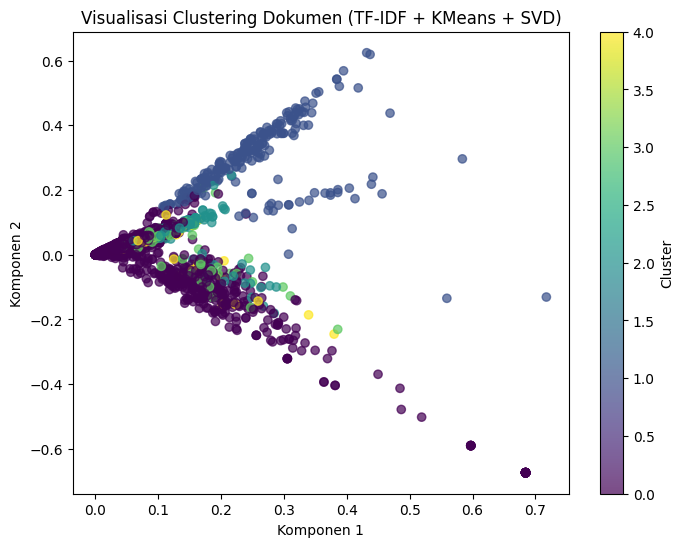


=== Contoh Email Tiap Cluster ===

Cluster 0:
Go until jurong point, crazy.. Available only i...
                     Ok lar... Joking wif u oni...
Free entry in 2 a wkly comp to win FA Cup final...

Cluster 1:
Great! I hope you like your man well endowed. I...
A gram usually runs like  &lt;#&gt; , a half ei...
Do you know what Mallika Sherawat did yesterday...

Cluster 2:
What you thinked about me. First time you saw m...
Sorry my roommates took forever, it ok if I com...
         Ela kano.,il download, come wen ur free..

Cluster 3:
Just forced myself to eat a slice. I'm really n...
For fear of fainting with the of all that house...
Hello! How's you and how did saturday go? I was...

Cluster 4:
 IÛ÷m going to try for 2 months ha ha only joking
Yup... Ok i go home look at the timings then i ...
                   Fair enough, anything going on?


In [2]:
# --- 1. Import Library ---
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# --- 2. Load Dataset ---
file_path = "spam.csv"  # pastikan file ada di folder kerja
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Jika dataset dari Kaggle (kolom v1 dan v2)
if 'v2' in df.columns:
    df = df.rename(columns={'v2': 'Text'})

df = df[['Text']].dropna()
print("Jumlah total data:", len(df))
display(df.head())

# --- 3. Inisialisasi Stopwords ---
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words()) | ENGLISH_STOP_WORDS

# --- 4. Fungsi Pembersihan Teks ---
def clean_text(text):
    text = str(text).lower()                      # ubah huruf ke kecil
    text = re.sub(r'[^a-z\s]', ' ', text)         # hapus karakter non-huruf
    text = ' '.join([word for word in text.split() if word not in stopwords])
    return text

# --- 5. Terapkan Pembersihan ---
df['cleaned_text'] = df['Text'].astype(str).apply(clean_text)
print("\nContoh hasil pembersihan teks:")
display(df[['Text', 'cleaned_text']].head())

# --- 6. TF-IDF Vectorization ---
def vectorize_text(data, max_features=3000):
    vectorizer = TfidfVectorizer(max_features=max_features)
    X_tfidf = vectorizer.fit_transform(data['cleaned_text'])
    return X_tfidf, vectorizer

X_tfidf, vectorizer = vectorize_text(df)
print(f"\nDimensi TF-IDF matrix: {X_tfidf.shape}")

# --- 7. Clustering dengan K-Means ---
def kmeans_clustering(X, k=5, random_state=42):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(X)
    return kmeans, clusters

k = 5
kmeans_model, clusters = kmeans_clustering(X_tfidf, k)
df['Cluster'] = clusters

# --- 8. Evaluasi dengan Silhouette Score ---
def evaluate_silhouette(X, clusters):
    score = silhouette_score(X, clusters)
    print(f"\nSilhouette Score: {score:.4f}")
    return score

evaluate_silhouette(X_tfidf, clusters)

# --- 9. Top Terms per Cluster ---
def top_terms_per_cluster(kmeans, vectorizer, n_terms=10):
    terms = vectorizer.get_feature_names_out()
    result = {}
    for i, center in enumerate(kmeans.cluster_centers_):
        top_idx = center.argsort()[-n_terms:][::-1]
        result[f"Cluster {i}"] = [terms[j] for j in top_idx]
    return result

top_words = top_terms_per_cluster(kmeans_model, vectorizer)
print("\n=== Kata Dominan per Cluster ===")
for cluster, words in top_words.items():
    print(f"{cluster}: {', '.join(words)}")

# --- 10. Visualisasi Cluster (TruncatedSVD) ---
def plot_clusters_svd(X, clusters):
    svd = TruncatedSVD(n_components=2, random_state=42)
    X_svd = svd.fit_transform(X)
    plt.figure(figsize=(8,6))
    plt.scatter(X_svd[:,0], X_svd[:,1], c=clusters, cmap='viridis', alpha=0.7)
    plt.title("Visualisasi Clustering Dokumen (TF-IDF + KMeans + SVD)")
    plt.xlabel("Komponen 1")
    plt.ylabel("Komponen 2")
    plt.colorbar(label='Cluster')
    plt.show()

plot_clusters_svd(X_tfidf, clusters)

# --- 11. Contoh Teks Tiap Cluster ---
def contoh_cluster(data, k):
    print("\n=== Contoh Email Tiap Cluster ===")
    for i in range(k):
        print(f"\nCluster {i}:")
        print(data[data['Cluster']==i]['Text'].head(3).to_string(index=False))

contoh_cluster(df, k)


In [ ]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
print("Jumlah total data:", len(df))
display(df.head())

text_column = 'Text' if 'Text' in df.columns else df.columns[0]

Jumlah total data: 5572


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Melakukan inisialisasi stopword dan pembersihan teks

In [4]:
# --- Stopwords manual ---
stop_words = set([
    "a","an","the","and","or","is","are","was","were","be","been","in","on","at",
    "to","for","of","by","with","as","that","this","it","from","but","not",
    "can","will","just","you","your","i","me","my","we","our","they","their"
])

# --- Fungsi pembersihan teks ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# --- Terapkan pembersihan ---
df['clean_text'] = df['Text'].astype(str).apply(clean_text)
print("\nContoh teks setelah dibersihkan:")
display(df[['Text','clean_text']].head())


Contoh teks setelah dibersihkan:


,Text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only bug...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think he goes usf he lives around her...


Representasi teks dengan TF-IDF

In [6]:
def vectorize_text(data, max_features=1000):
    vectorizer = TfidfVectorizer(max_features=max_features)
    X_tfidf = vectorizer.fit_transform(data['clean_text'])
    return X_tfidf, vectorizer

X_tfidf, vectorizer = vectorize_text(df)
print(f"\nDimensi TF-IDF matrix: {X_tfidf.shape}")


Dimensi TF-IDF matrix: (5572, 1000)


Clustering dengan K-Means

In [15]:
def kmeans_clustering(X, k=3, random_state=42):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(X)
    return kmeans, clusters

k = 5
kmeans_model, clusters = kmeans_clustering(X_tfidf, k)
df['Cluster'] = clusters

Evaluasi kualitas Clustering

In [8]:
def evaluate_silhouette(X, clusters):
    score = silhouette_score(X, clusters)
    print(f"\nSilhouette Score: {score:.4f}")
    return score

evaluate_silhouette(X_tfidf, clusters)


Silhouette Score: 0.0086


0.008618194914247415

Menampilkan Kata Dominan per Cluster

In [16]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]

clusters_top_words = []  # untuk menyimpan hasil

for i in range(k):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    clusters_top_words.append({
        "Cluster": i,
        "Top Words": ', '.join(top_words)
    })

df_top_words = pd.DataFrame(clusters_top_words)
display(df_top_words)

,Cluster,Top Words
0,0,"have, do, so, get, what, ur, how, up, now, its"
1,1,"no, need, nokia, txt, ur, ltgt, get, free, sto..."
2,2,"im, now, home, so, going, when, gonna, call, d..."
3,3,"ok, lor, then, its, thanx, if, ill, ur, come, go"
4,4,"call, later, sorry, free, now, claim, prize, i..."


Menampilkan visualisasi hasil clustering

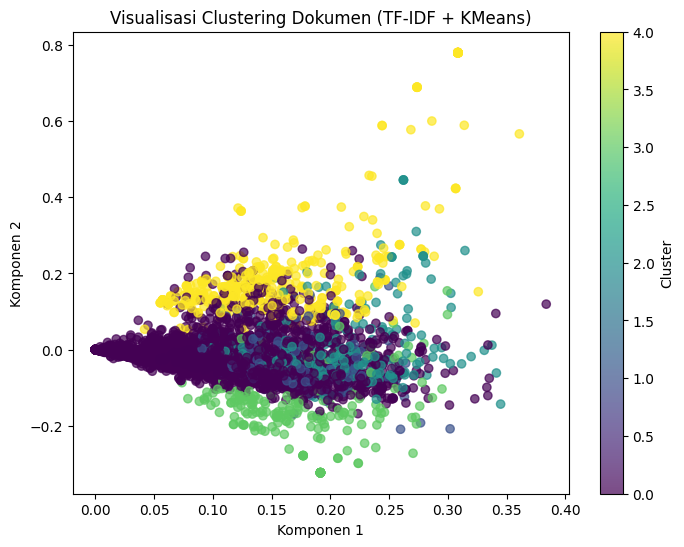

In [19]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

def plot_clusters_svd(X, clusters):
    svd = TruncatedSVD(n_components=2, random_state=42)
    reduced_data = svd.fit_transform(X)

    plt.figure(figsize=(8,6))
    plt.scatter(reduced_data[:, 0], reduced_data[:, 1],
                c=clusters, cmap='viridis', alpha=0.7)
    plt.title("Visualisasi Clustering Dokumen (TF-IDF + KMeans)")
    plt.xlabel("Komponen 1")
    plt.ylabel("Komponen 2")
    plt.colorbar(label='Cluster')
    plt.show()

# --- Panggil fungsi ---
plot_clusters_svd(X_tfidf, clusters)


Menampilkan Contoh Email Tiap Cluster

In [27]:
text_column = 'Text'  # pastikan kolomnya benar

for i in range(k):
    print(f"\n=== Contoh Email Cluster {i} ===")
    display(df[df['Cluster']==i][[text_column]].head(3))


=== Contoh Email Cluster 0 ===


,Text
0,"Go until jurong point, crazy.. Available only ..."
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...



=== Contoh Email Cluster 1 ===


,Text
5,FreeMsg Hey there darling it's been 3 week's n...
12,URGENT! You have won a 1 week FREE membership ...
24,Ffffffffff. Alright no way I can meet up with ...



=== Contoh Email Cluster 2 ===


,Text
10,I'm gonna be home soon and i don't want to tal...
21,IÛ÷m going to try for 2 months ha ha only joking
25,Just forced myself to eat a slice. I'm really ...



=== Contoh Email Cluster 3 ===


,Text
1,Ok lar... Joking wif u oni...
35,Yup... Ok i go home look at the timings then i...
63,"Sorry my roommates took forever, it ok if I co..."



=== Contoh Email Cluster 4 ===


,Text
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...
42,07732584351 - Rodger Burns - MSG = We tried to...
